# Preprocessing and Data Cleaning

This notebook reads the raw Borg trace CSV, reconstructs timestamps from 2019-05-01, removes duplicate/zero time gaps through aggregation, resamples to a uniform interval, and writes cleaned plus model-specific CSV files.

In [19]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT / "src"))

from forecast_utils import *

raw_path = resolve_raw_csv()
raw_path

WindowsPath('C:/Users/Radhika_2004/Minor Project_sem 7/borg_traces_data.csv')

In [20]:
MAX_ROWS = 300_000  # Increase or set to None if your machine can handle the full dataset.
df = load_csv(raw_path, max_rows=MAX_ROWS)
print(df.shape)
df.head()

(300000, 34)


,Unnamed: 0,time,instance_events_type,collection_id,scheduling_class,collection_type,priority,alloc_collection_id,instance_index,machine_id,...,assigned_memory,page_cache_memory,cycles_per_instruction,memory_accesses_per_instruction,sample_rate,cpu_usage_distribution,tail_cpu_usage_distribution,cluster,event,failed
0,0,0,2,94591244395,3,1,200,0,144,168846390496,...,0.014435,0.000415,NaN,NaN,1.0,[0.00314331 0.00381088 0.00401306 0.00415039 0...,[0.00535583 0.00541687 0.00548553 0.00554657 0...,7,FAIL,1
1,1,2517305308183,2,260697606809,2,0,360,221495397286,335,85515092,...,0.000000,0.000000,NaN,NaN,1.0,[1.23977661e-05 1.23977661e-05 1.23977661e-05 ...,[1.23977661e-05 1.23977661e-05 1.23977661e-05 ...,7,FAIL,1
2,2,195684022913,6,276227177776,2,0,103,0,376,169321752432,...,0.010422,0.000235,0.939919,0.001318,1.0,[0.01344299 0.01809692 0.0201416 0.02246094 0...,[0.02902222 0.02929688 0.0295105 0.0296936 0...,7,SCHEDULE,0
3,3,0,2,10507389885,3,0,200,0,1977,178294817221,...,0.041626,0.000225,1.359102,0.007643,1.0,[0.03704834 0.04125977 0.04290771 0.04425049 0...,[0.05535889 0.05584717 0.05633545 0.05718994 0...,8,FAIL,1
4,4,1810627494172,3,25911621841,2,0,0,0,3907,231364893292,...,0.000272,0.000010,NaN,NaN,1.0,[0. 0. 0. 0. 0...,[0.00041485 0.00041485 0.00041485 0.00041485 0...,2,FINISH,0


In [21]:
df.columns.tolist()

['Unnamed: 0',
 'time',
 'instance_events_type',
 'collection_id',
 'scheduling_class',
 'collection_type',
 'priority',
 'alloc_collection_id',
 'instance_index',
 'machine_id',
 'resource_request',
 'constraint',
 'collections_events_type',
 'user',
 'collection_name',
 'collection_logical_name',
 'start_after_collection_ids',
 'vertical_scaling',
 'scheduler',
 'start_time',
 'end_time',
 'average_usage',
 'maximum_usage',
 'random_sample_usage',
 'assigned_memory',
 'page_cache_memory',
 'cycles_per_instruction',
 'memory_accesses_per_instruction',
 'sample_rate',
 'cpu_usage_distribution',
 'tail_cpu_usage_distribution',
 'cluster',
 'event',
 'failed']

In [22]:
time_col = find_column(df, ["start_time", "starttime", "time", "timestamp", "start"])
cpu_col = find_column(df, ["average_usage", "cpu_usage", "cpu_utilization", "average_usage.cpus", "cpus", "cpu"])
print("Time column:", time_col)
print("CPU column:", cpu_col)

Time column: start_time
CPU column: average_usage


In [23]:
INTERVAL = "5min"
working, aggregated, series = clean_cpu_timeseries(
    df,
    time_col=time_col,
    cpu_col=cpu_col,
    start="2019-05-01",
    interval=INTERVAL,
)
working.head()

,timestamp,cpu_utilization
183421,2019-05-01 00:00:00,0.036865
154472,2019-05-01 00:05:00,0.000432
210475,2019-05-01 00:05:00,0.000432
251635,2019-05-01 00:05:00,0.000432
50687,2019-05-01 00:05:00,0.000432


In [24]:
duplicate_count = working["timestamp"].duplicated().sum()
zero_diffs = (working["timestamp"].diff() == pd.Timedelta(0)).sum()
print("Duplicate timestamps:", duplicate_count)
print("Zero time differences:", zero_diffs)
print("Uniform interval:", INTERVAL)
series.head()

Duplicate timestamps: 296117
Zero time differences: 296117
Uniform interval: 5min


,timestamp,cpu_utilization
0,2019-05-01 00:00:00,0.036865
1,2019-05-01 00:05:00,0.000414
2,2019-05-01 00:10:00,0.001263
3,2019-05-01 00:15:00,0.002420
4,2019-05-01 00:20:00,0.013458


In [25]:
print(series.shape)
print(series["timestamp"].diff().value_counts().head())
series.describe()

(8928, 2)
timestamp
0 days 00:05:00    8927
Name: count, dtype: int64


,timestamp,cpu_utilization
count,8928,8928.000000
mean,2019-05-16 11:57:30,0.008236
min,2019-05-01 00:00:00,0.000000
25%,2019-05-08 17:58:45,0.000745
50%,2019-05-16 11:57:30,0.003669
75%,2019-05-24 05:56:15,0.009896
max,2019-05-31 23:55:00,0.527344
std,NaN,0.015786


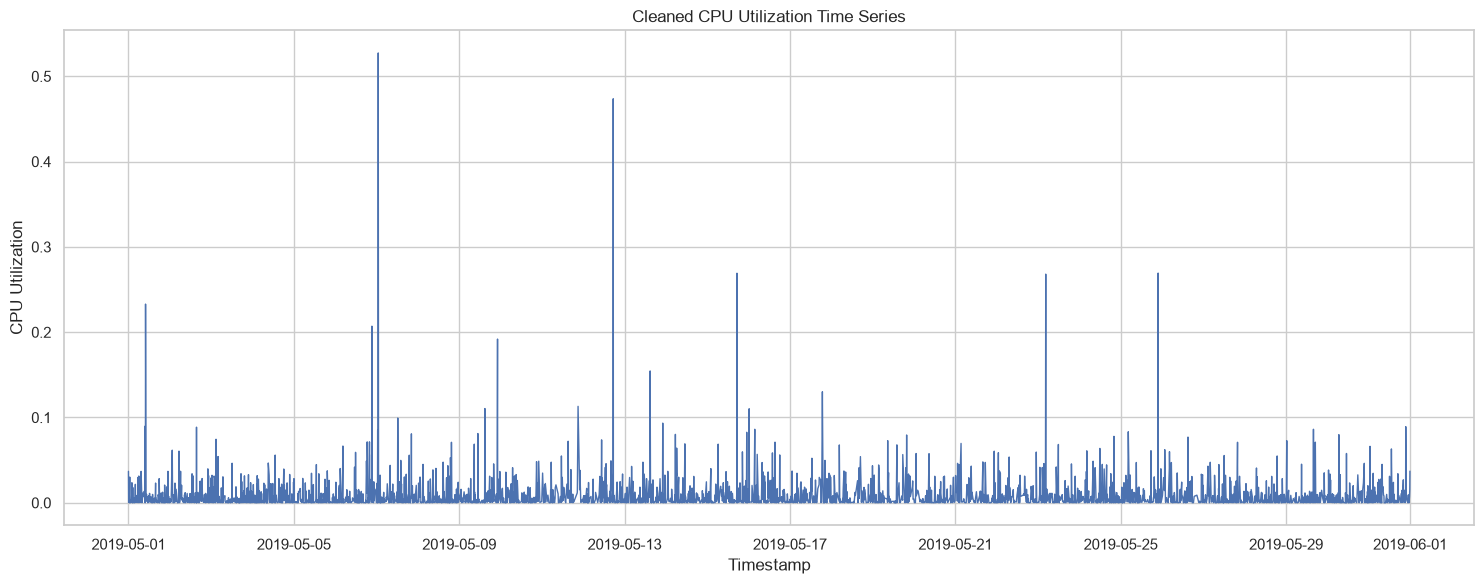

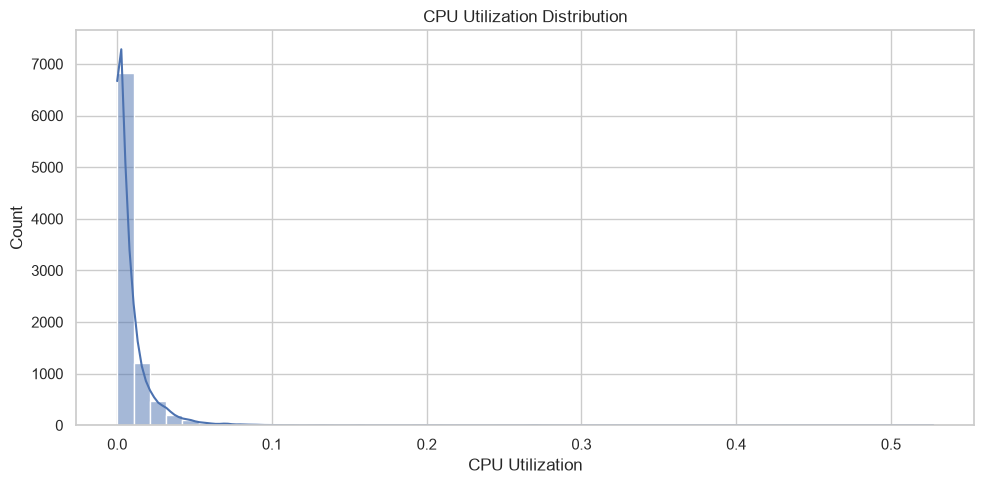

In [26]:
plt.figure(figsize=(15, 6))
plt.plot(series["timestamp"], series["cpu_utilization"], linewidth=1)
plt.title("Cleaned CPU Utilization Time Series")
plt.xlabel("Timestamp")
plt.ylabel("CPU Utilization")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "cleaned_cpu_utilization_timeseries.png", dpi=160)
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(series["cpu_utilization"], bins=50, kde=True)
plt.title("CPU Utilization Distribution")
plt.xlabel("CPU Utilization")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "cpu_utilization_distribution.png", dpi=160)
plt.show()

In [27]:
cleaned_path = DATA_DIR / "cleaned_cpu_utilization.csv"
series.to_csv(cleaned_path, index=False)

series.to_csv(DATA_DIR / "persistence_data.csv", index=False)
series.to_csv(DATA_DIR / "arima_data.csv", index=False)

X, y, supervised = make_supervised(series.set_index("timestamp")["cpu_utilization"], lags=12, horizon=1)
supervised.reset_index().rename(columns={"index": "timestamp"}).to_csv(DATA_DIR / "xgboost_data.csv", index=False)

lstm_df = series.copy()
lstm_df.to_csv(DATA_DIR / "lstm_data.csv", index=False)

print("Created:")
for path in sorted(DATA_DIR.glob("*.csv")):
    print(path.name)

Created:
arima_data.csv
cleaned_cpu_utilization.csv
lstm_data.csv
persistence_data.csv
xgboost_data.csv
